In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [3]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Load your dataset
df = pd.read_csv(r'C:\Users\User\Desktop\FINAL YEAR PROJECT\Data\ROI\crop_yield.csv')

# Encode categorical columns
le_crop = LabelEncoder()
le_state = LabelEncoder()
le_season = LabelEncoder()

df['crop_encoded'] = le_crop.fit_transform(df['Crop'])
df['location_encoded'] = le_state.fit_transform(df['State'])
df['season_encoded'] = le_season.fit_transform(df['Season'])

# Create investment column
df['investment'] = df['Fertilizer'] + df['Pesticide']

# Calculate ROI with fixed price
fixed_price = 30
df['roi'] = (df['Yield'] * fixed_price - df['investment']) / df['investment'] * 100

# Features and target
X = df[['crop_encoded', 'Area', 'location_encoded', 'investment', 'season_encoded']]
y = df['roi']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_model.fit(X_train, y_train)

# Evaluate
y_pred = gbr_model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 226.38127470902364
R2 Score: 0.6234985077909145


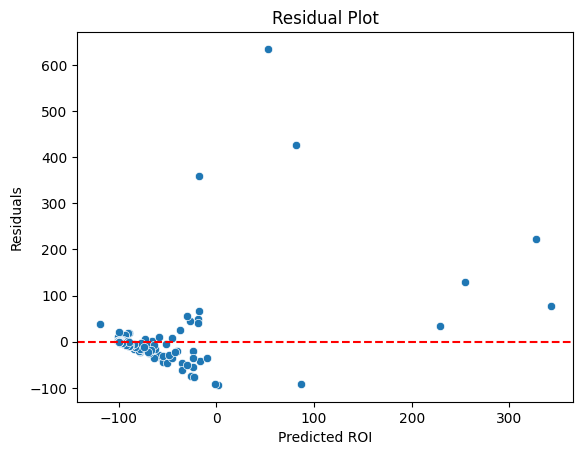

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted ROI')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()



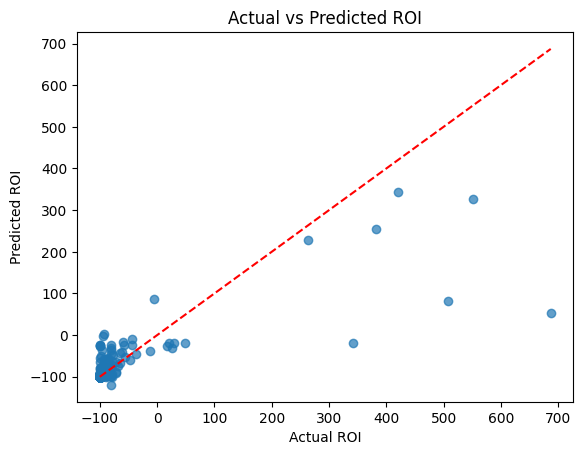

In [6]:
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual ROI')
plt.ylabel('Predicted ROI')
plt.title('Actual vs Predicted ROI')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal line
plt.show()


In [8]:
with open('roi_prediction_model.pkl', 'wb') as file:
    pickle.dump(gbr_model, file)

print("Model saved successfully as 'roi_prediction_model.pkl'")



Model saved successfully as 'roi_prediction_model.pkl'
